**Customer Churn Prediction**

In [ ]:
# =============================================
# Step 1 — Install & Import Required Libraries
# =============================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import joblib

print("✅ All libraries imported successfully!")

✅ All libraries imported successfully!


In [ ]:
# =============================================
# Step 2 — Load the Dataset
# =============================================

df = pd.read_csv("/content/WA_Fn-UseC_-Telco-Customer-Churn.csv")

print("Shape:", df.shape)
print("\nFirst 5 rows:")
df.head()

Shape: (7043, 21)

First 5 rows:


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [ ]:
# =============================================
# Step 3 — Explore the Dataset
# =============================================

print("📊 Dataset Info:")
print(df.info())

print("\n📈 Basic Statistics:")
print(df.describe())

print("\n❓ Missing Values:")
print(df.isnull().sum())

print("\n🎯 Churn Value Counts:")
print(df['Churn'].value_counts())

📊 Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non

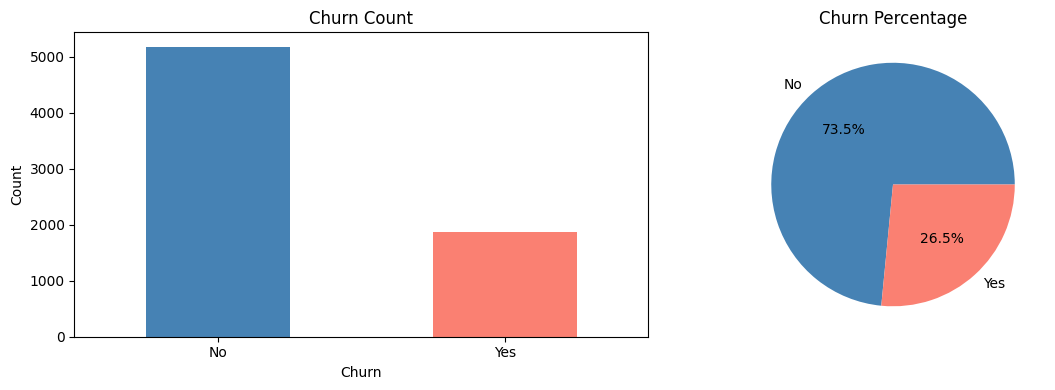

In [ ]:
# =============================================
# Step 4 — Visualize Churn Distribution
# =============================================

plt.figure(figsize=(12, 4))

# Churn count
plt.subplot(1, 2, 1)
df['Churn'].value_counts().plot(kind='bar', color=['steelblue', 'salmon'])
plt.title("Churn Count")
plt.xlabel("Churn")
plt.ylabel("Count")
plt.xticks(rotation=0)

# Churn percentage
plt.subplot(1, 2, 2)
df['Churn'].value_counts().plot(kind='pie', autopct='%1.1f%%', colors=['steelblue', 'salmon'])
plt.title("Churn Percentage")
plt.ylabel("")

plt.tight_layout()
plt.show()

In [ ]:
# =============================================
# Step 5 — Clean and Preprocess the Data
# =============================================

# Fix TotalCharges column (stored as string)
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')

# Drop rows with missing values
df.dropna(inplace=True)

# Drop customerID (not useful for prediction)
df.drop('customerID', axis=1, inplace=True)

print("✅ Data cleaned!")
print("New shape:", df.shape)

✅ Data cleaned!
New shape: (7032, 20)


In [ ]:
# =============================================
# Step 6 — Encode Categorical Columns to Numbers
# =============================================

le = LabelEncoder()

for col in df.select_dtypes(include='object').columns:
    df[col] = le.fit_transform(df[col])
    print(f"✅ Encoded: {col}")

print("\nData after encoding:")
df.head()

✅ Encoded: gender
✅ Encoded: Partner
✅ Encoded: Dependents
✅ Encoded: PhoneService
✅ Encoded: MultipleLines
✅ Encoded: InternetService
✅ Encoded: OnlineSecurity
✅ Encoded: OnlineBackup
✅ Encoded: DeviceProtection
✅ Encoded: TechSupport
✅ Encoded: StreamingTV
✅ Encoded: StreamingMovies
✅ Encoded: Contract
✅ Encoded: PaperlessBilling
✅ Encoded: PaymentMethod
✅ Encoded: Churn

Data after encoding:


,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,0,0,1,0,1,0,1,0,0,2,0,0,0,0,0,1,2,29.85,29.85,0
1,1,0,0,0,34,1,0,0,2,0,2,0,0,0,1,0,3,56.95,1889.50,0
2,1,0,0,0,2,1,0,0,2,2,0,0,0,0,0,1,3,53.85,108.15,1
3,1,0,0,0,45,0,1,0,2,0,2,2,0,0,1,0,0,42.30,1840.75,0
4,0,0,0,0,2,1,0,1,0,0,0,0,0,0,0,1,2,70.70,151.65,1


In [ ]:
# =============================================
# Step 7 — Split Dataset into Training and Testing Sets
# =============================================

X = df.drop('Churn', axis=1)  # Features
y = df['Churn']                # Target

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("✅ Data split done!")
print(f"Training samples  : {X_train.shape[0]}")
print(f"Testing samples   : {X_test.shape[0]}")
print(f"Total features    : {X_train.shape[1]}")

✅ Data split done!
Training samples  : 5625
Testing samples   : 1407
Total features    : 19


In [ ]:
# =============================================
# Step 8 — Train Random Forest Classifier
# =============================================

model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

print("✅ Model trained successfully!")
print(f"Number of trees   : {model.n_estimators}")
print(f"Number of features: {model.n_features_in_}")

✅ Model trained successfully!
Number of trees   : 100
Number of features: 19


In [ ]:
# =============================================
# Step 9 — Evaluate Model Performance
# =============================================

y_pred = model.predict(X_test)

print("🎯 Accuracy Score:", round(accuracy_score(y_test, y_pred) * 100, 2), "%")
print("\n📋 Classification Report:")
print(classification_report(y_test, y_pred, target_names=['Not Churn', 'Churn']))

🎯 Accuracy Score: 79.25 %

📋 Classification Report:
              precision    recall  f1-score   support

   Not Churn       0.83      0.90      0.86      1033
       Churn       0.64      0.49      0.56       374

    accuracy                           0.79      1407
   macro avg       0.74      0.70      0.71      1407
weighted avg       0.78      0.79      0.78      1407



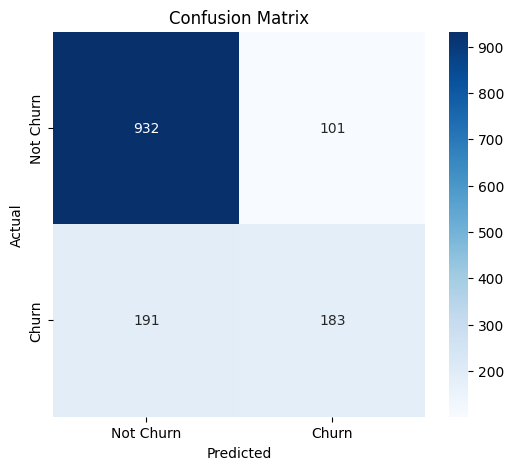

✅ True Not Churn  : 932
❌ False Churn     : 101
❌ Missed Churn    : 191
✅ True Churn      : 183


In [ ]:
# =============================================
# Step 10 — Plot Confusion Matrix
# =============================================

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Not Churn', 'Churn'],
            yticklabels=['Not Churn', 'Churn'])
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

print(f"✅ True Not Churn  : {cm[0][0]}")
print(f"❌ False Churn     : {cm[0][1]}")
print(f"❌ Missed Churn    : {cm[1][0]}")
print(f"✅ True Churn      : {cm[1][1]}")

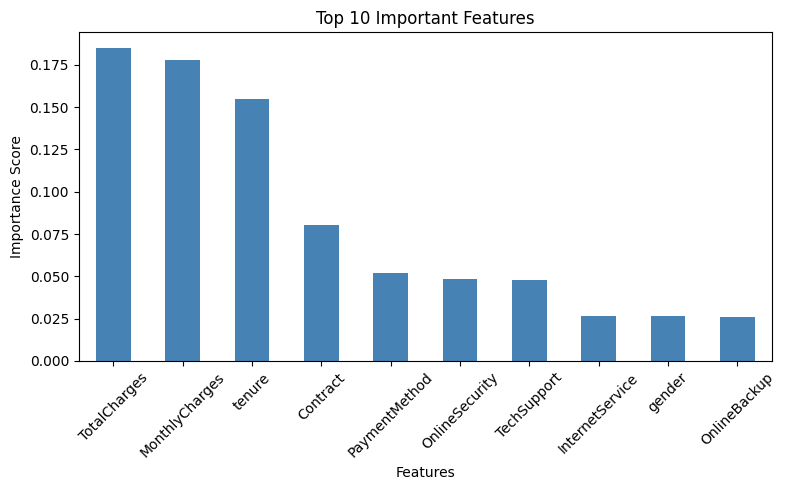


🏆 Top 10 Features:
1. TotalCharges: 0.1850
2. MonthlyCharges: 0.1780
3. tenure: 0.1545
4. Contract: 0.0806
5. PaymentMethod: 0.0520
6. OnlineSecurity: 0.0485
7. TechSupport: 0.0476
8. InternetService: 0.0268
9. gender: 0.0267
10. OnlineBackup: 0.0259


In [ ]:
# =============================================
# Step 11 — Plot Top 10 Most Important Features
# =============================================

feat_imp = pd.Series(model.feature_importances_, index=X.columns)
feat_imp = feat_imp.sort_values(ascending=False)[:10]

plt.figure(figsize=(8, 5))
feat_imp.plot(kind='bar', color='steelblue')
plt.title("Top 10 Important Features")
plt.xlabel("Features")
plt.ylabel("Importance Score")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

print("\n🏆 Top 10 Features:")
for i, (feature, score) in enumerate(feat_imp.items(), 1):
    print(f"{i}. {feature}: {score:.4f}")

In [ ]:
# =============================================
# Step 12 — Predict Churn for a New Customer
# =============================================
print("📋 Please enter customer details:")
print("="*45)
gender = int(input("Gender (0=Female, 1=Male): "))
SeniorCitizen = int(input("Senior Citizen (0=No, 1=Yes): "))
Partner = int(input("Partner (0=No, 1=Yes): "))
Dependents = int(input("Dependents (0=No, 1=Yes): "))
tenure = int(input("Tenure (months, e.g. 12): "))
PhoneService = int(input("Phone Service (0=No, 1=Yes): "))
MultipleLines = int(input("Multiple Lines (0=No, 1=Yes, 2=No phone): "))
InternetService = int(input("Internet Service (0=DSL, 1=Fiber, 2=No): "))
OnlineSecurity = int(input("Online Security (0=No, 1=Yes, 2=No internet): "))
OnlineBackup = int(input("Online Backup (0=No, 1=Yes, 2=No internet): "))
DeviceProtection = int(input("Device Protection (0=No, 1=Yes, 2=No internet): "))
TechSupport = int(input("Tech Support (0=No, 1=Yes, 2=No internet): "))
StreamingTV = int(input("Streaming TV (0=No, 1=Yes, 2=No internet): "))
StreamingMovies = int(input("Streaming Movies (0=No, 1=Yes, 2=No internet): "))
Contract = int(input("Contract (0=Month-to-month, 1=One year, 2=Two year): "))
PaperlessBilling = int(input("Paperless Billing (0=No, 1=Yes): "))
PaymentMethod = int(input("Payment Method (0=Bank transfer, 1=Credit card, 2=Electronic check, 3=Mailed check): "))
MonthlyCharges = float(input("Monthly Charges (e.g. 65.5): "))
TotalCharges = float(input("Total Charges (e.g. 1200.0): "))
print("="*45)
# Create input as DataFrame to avoid warning
user_input = pd.DataFrame([[gender, SeniorCitizen, Partner, Dependents, tenure,
               PhoneService, MultipleLines, InternetService, OnlineSecurity,
               OnlineBackup, DeviceProtection, TechSupport, StreamingTV,
               StreamingMovies, Contract, PaperlessBilling, PaymentMethod,
               MonthlyCharges, TotalCharges]], columns=X.columns)
# Predict
prediction = model.predict(user_input)
probability = model.predict_proba(user_input)[0]
print("\n" + "="*45)
print("🔮 Prediction:", "⚠️ CHURN" if prediction[0] == 1 else "✅ NOT CHURN")
print(f"📊 Probability → Not Churn: {probability[0]:.2f} | Churn: {probability[1]:.2f}")
print("="*45)

📋 Please enter customer details:
Gender (0=Female, 1=Male): 1
Senior Citizen (0=No, 1=Yes): 0
Partner (0=No, 1=Yes): 1
Dependents (0=No, 1=Yes): 0
Tenure (months, e.g. 12): 6
Phone Service (0=No, 1=Yes): 1
Multiple Lines (0=No, 1=Yes, 2=No phone): 1
Internet Service (0=DSL, 1=Fiber, 2=No): 1
Online Security (0=No, 1=Yes, 2=No internet): 0
Online Backup (0=No, 1=Yes, 2=No internet): 1
Device Protection (0=No, 1=Yes, 2=No internet): 1
Tech Support (0=No, 1=Yes, 2=No internet): 1
Streaming TV (0=No, 1=Yes, 2=No internet): 0
Streaming Movies (0=No, 1=Yes, 2=No internet): 1
Contract (0=Month-to-month, 1=One year, 2=Two year): 2
Paperless Billing (0=No, 1=Yes): 1
Payment Method (0=Bank transfer, 1=Credit card, 2=Electronic check, 3=Mailed check): 1
Monthly Charges (e.g. 65.5): 45
Total Charges (e.g. 1200.0): 2000

🔮 Prediction: ✅ NOT CHURN
📊 Probability → Not Churn: 0.82 | Churn: 0.18
